In [1]:
# Transformer-stock-price-demo.ipynb
# Sept 27, 2026
#
# This is a demo of an PyTorch implementation of a transformer time series forecasting example.
# It uses the previous 20 days of stock price of the Apple (ASPL) stock to predict the next value.
# The daily closing price is used and the model takes the previous 20 trading days as input
# to predict the next closing price, and then recursively forecasts multiple future values.
# The transformer is the machine learning model used for training. The dataset is aapl_demo.csv.

# On the transformer architecture, take note of the manual PyTorch implementation of the
# scaled dot product and the attention mechanism.  The usual built-in function TransformerEncoder
# or the TransformerEncoderLayer is not used. Pay attention to the dimension of the matrices.


In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. Configuration
# =========================================================
LOOKBACK = 20
BATCH_SIZE = 16
NUM_EPOCHS = 300
LR = 1e-3

D_MODEL = 64
NHEAD = 4
NUM_LAYERS = 2
DIM_FEEDFORWARD = 128
DROPOUT = 0.1

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

from google.colab import drive
drive.mount('/content/drive')

Using device: cpu
Mounted at /content/drive


In [4]:
print("First, to illustrate matrix multiplication:")

K_demo = np.array([[1.0, 0.0, 0.5, 0.2], [0.0, 1.0, 0.8, 0.4]])
K_demo_new = np.swapaxes(K_demo, -1, -2)
print(K_demo)
print(K_demo_new)
print("K_demo.shape (2 x 4 matrix) = ", K_demo.shape)
print("K_demo_new.shape (4 x 2 matrix) = ", K_demo_new.shape)


result_demo = np.matmul(K_demo,K_demo_new)
print("result_demo (2 x 2 matrix) = ")
print(result_demo)

First, to illustrate matrix multiplication:
[[1.  0.  0.5 0.2]
 [0.  1.  0.8 0.4]]
[[1.  0. ]
 [0.  1. ]
 [0.5 0.8]
 [0.2 0.4]]
K_demo.shape (2 x 4 matrix) =  (2, 4)
K_demo_new.shape (4 x 2 matrix) =  (4, 2)
result_demo (2 x 2 matrix) = 
[[1.29 0.48]
 [0.48 1.8 ]]


In [11]:
print("To illustrate the softmax operation:")

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

scores = np.array([[2, 1], [1, 3]])
print("scores simulates the scaled dot-product scores")
print("scores")
print(scores)
weights = softmax(scores)
print("weights")
print(weights)
print("Note that sum of both rows are 1.")


To illustrate the softmax operation:
scores simulates the scaled dot-product scores
scores
[[2 1]
 [1 3]]
weights
[[0.73105858 0.26894142]
 [0.11920292 0.88079708]]
Note that sum of both rows are 1.


In [19]:
# =========================================================
# 2. Utility functions
# =========================================================
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

def scaled_dot_product_attention_numpy(Q, K, V):
    d_k = 2
    scores = np.matmul(Q, np.swapaxes(K, -1, -2)) / np.sqrt(d_k)
    weights = softmax(scores)
    return np.matmul(weights, V), weights


# Tiny educational NumPy demo
Q_demo = np.array([[1.0, 0.5, 2.0], [0.0, 3.0, 1.5]])
K_demo = np.array([[2.0, 1.0, 2.5], [ 0.5, 0.2, 0.8]])
V_demo = np.array([[10.0, 1.0, 3.9], [2.0, 20.0, 1.0]])

print(Q_demo)
print(K_demo)
print(V_demo)
print("Q_demo.shape = ", Q_demo.shape)
print("K_demo.shape = ", K_demo.shape)
print(" ----------------------------------------------- ")
output_demo, attention_weights_demo = scaled_dot_product_attention_numpy(Q_demo, K_demo, V_demo)

print("Tiny demo of NumPy scaled dot-product attention demo output:\n", output_demo)
print("output_demo.shape = ", output_demo.shape)
print(" ----------------------------------------------- ")
print("Tiny demo of NumPy attention weights:\n", attention_weights_demo)
print("attention_weights_demo.shape = ", attention_weights_demo.shape)
print(" ----------------------------------------------- ")


[[1.  0.5 2. ]
 [0.  3.  1.5]]
[[2.  1.  2.5]
 [0.5 0.2 0.8]]
[[10.   1.   3.9]
 [ 2.  20.   1. ]]
Q_demo.shape =  (2, 3)
K_demo.shape =  (2, 3)
 ----------------------------------------------- 
Tiny demo of NumPy scaled dot-product attention demo output:
 [[9.81576139 1.4375667  3.8332135 ]
 [9.7655428  1.55683586 3.81500926]]
output_demo.shape =  (2, 3)
 ----------------------------------------------- 
Tiny demo of NumPy attention weights:
 [[0.97697017 0.02302983]
 [0.97069285 0.02930715]]
attention_weights_demo.shape =  (2, 2)
 ----------------------------------------------- 


Number of rows =  68
---------------------------------------------
To display the first five rows in the dataset
        Date        Open        High         Low       Close   Adj Close  \
0 2020-12-07  122.309998  124.570000  122.250000  123.750000  121.447411   
1 2020-12-08  124.370003  124.980003  123.089996  124.379997  122.065681   
2 2020-12-09  124.529999  125.949997  121.000000  121.779999  119.514076   
3 2020-12-10  120.500000  123.870003  120.150002  123.239998  120.946907   
4 2020-12-11  122.430000  122.760002  120.550003  122.410004  120.132362   

      Volume  
0   86712000  
1   82225500  
2  115089200  
3   81312200  
4   86939800  
Rows: 68


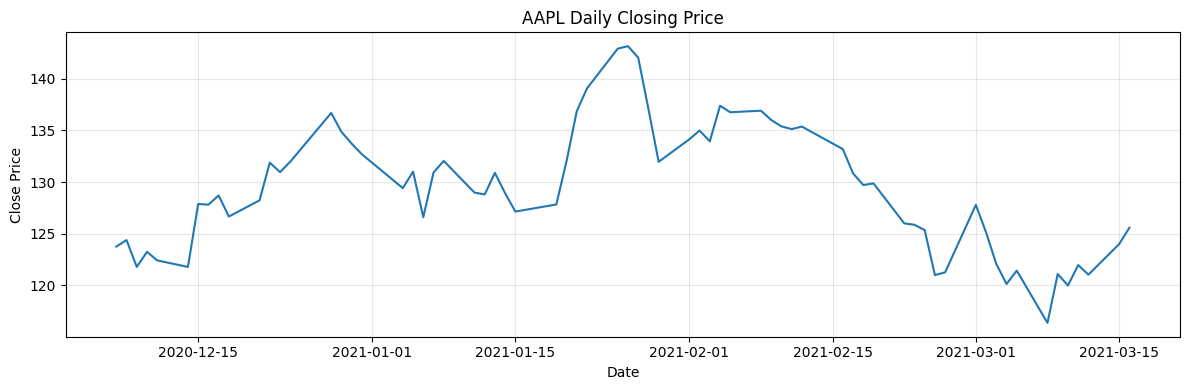

In [20]:
# =========================================================
# 3. Load dataset
# =========================================================
df = pd.read_csv("/content/drive/My Drive/Colab Notebooks/elec6604python/aapl_demo.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

series = df["Close"].astype("float32").values

print("Number of rows = ", len(df["Date"]))
print("---------------------------------------------")
print("To display the first five rows in the dataset")

print(df.head())
print("Rows:", len(df))

plt.figure(figsize=(12, 4))
plt.plot(df["Date"], series)
plt.title("AAPL Daily Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# =========================================================
# 4. Train-test split and scaling
# =========================================================
train_ratio = 0.8
split_idx = int(len(series) * train_ratio)

train_series = series[:split_idx]
test_series = series[split_idx:]

print("split_idx = ", split_idx)
print("train_series has items = ", len(train_series))
print("test_series has items = ", len(test_series))
print("----------------------------")

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_series.reshape(-1, 1)).flatten()
test_scaled = scaler.transform(test_series.reshape(-1, 1)).flatten()

print("Train size:", len(train_series))
print("Test size:", len(test_series))

# =========================================================
# 5. Create sliding windows
# =========================================================
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i + lookback])
        y.append(data[i + lookback])

    X = np.array(X, dtype=np.float32).reshape(-1, lookback, 1)
    y = np.array(y, dtype=np.float32).reshape(-1, 1)
    return torch.tensor(X), torch.tensor(y)

X_train, y_train = create_sequences(train_scaled, LOOKBACK)

test_with_context = np.concatenate([train_scaled[-LOOKBACK:], test_scaled])
X_test, y_test = create_sequences(test_with_context, LOOKBACK)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)
print("-----------------------------------------------------")
print("X_train and X_test are input sequences of 20 values).")

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=BATCH_SIZE,
    shuffle=False
)


split_idx =  54
train_series has items =  54
test_series has items =  14
----------------------------
Train size: 54
Test size: 14
X_train: torch.Size([34, 20, 1])
y_train: torch.Size([34, 1])
X_test : torch.Size([14, 20, 1])
y_test : torch.Size([14, 1])
-----------------------------------------------------
X_train and X_test are input sequences of 20 values).


In [22]:
# =========================================================
# 6. Positional encoding
# =========================================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32)
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)   # (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]

In [23]:
# =========================================================
# 7. Manual scaled dot-product attention in PyTorch
# =========================================================
class ScaledDotProductAttention(nn.Module):
    def __init__(self, dropout=0.0):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

    def forward(self, Q, K, V, mask=None):
        # Q, K, V: (batch, heads, seq_len, d_k)
        d_k = Q.size(-1)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

        if mask is not None:
            # mask should be broadcastable to (batch, heads, seq_len, seq_len)
            scores = scores.masked_fill(mask == 0, float("-inf"))

        attn_weights = torch.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        output = torch.matmul(attn_weights, V)
        return output, attn_weights

In [24]:
# =========================================================
# 8. Manual multi-head self-attention
# =========================================================
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, nhead, dropout=0.1):
        super().__init__()

        assert d_model % nhead == 0, "d_model must be divisible by nhead"

        self.d_model = d_model
        self.nhead = nhead
        self.d_k = d_model // nhead

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        self.attention = ScaledDotProductAttention(dropout=dropout)


    def forward(self, x, mask=None):
        # x: (batch, seq_len, d_model)
        batch_size, seq_len, _ = x.shape

        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        # reshape to (batch, heads, seq_len, d_k)
        Q = Q.view(batch_size, seq_len, self.nhead, self.d_k).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.nhead, self.d_k).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.nhead, self.d_k).transpose(1, 2)

        attn_output, attn_weights = self.attention(Q, K, V, mask=mask)

        # merge heads back: (batch, seq_len, d_model)
        attn_output = attn_output.transpose(1, 2).contiguous().view(
            batch_size, seq_len, self.d_model
        )

        output = self.W_o(attn_output)
        return output, attn_weights


In [25]:
# =========================================================
# 9. Feedforward block
# =========================================================
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, dim_feedforward, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model)
        )

    def forward(self, x):
        return self.net(x)


In [26]:
# =========================================================
# 10. Manual transformer encoder block
# =========================================================
class TransformerBlock(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward, dropout=0.1):
        super().__init__()

        self.self_attn = MultiHeadSelfAttention(
            d_model=d_model,
            nhead=nhead,
            dropout=dropout
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)

        self.ffn = PositionwiseFeedForward(
            d_model=d_model,
            dim_feedforward=dim_feedforward,
            dropout=dropout
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attn_output, attn_weights = self.self_attn(x, mask=mask)
        x = self.norm1(x + self.dropout1(attn_output))

        ffn_output = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_output))

        return x, attn_weights

In [27]:
# =========================================================
# 11. Full transformer forecasting model
# =========================================================
class TimeSeriesTransformer(nn.Module):
    def __init__(
        self,
        input_size=1,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.1,
        max_len=500
    ):
        super().__init__()

        self.input_projection = nn.Linear(input_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_len=max_len)

        self.layers = nn.ModuleList([
            TransformerBlock(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=dim_feedforward,
                dropout=dropout
            )
            for _ in range(num_layers)
        ])

        self.output_head = nn.Linear(d_model, 1)

    def generate_causal_mask(self, seq_len, device):
        # shape: (1, 1, seq_len, seq_len)
        mask = torch.tril(torch.ones(seq_len, seq_len, device=device)).unsqueeze(0).unsqueeze(0)
        return mask

    def forward(self, x, return_attention=False):
        # x: (batch, seq_len, 1)
        x = self.input_projection(x)
        x = self.positional_encoding(x)

        seq_len = x.size(1)
        mask = self.generate_causal_mask(seq_len, x.device)

        all_attention = []

        for layer in self.layers:
            x, attn_weights = layer(x, mask=mask)
            all_attention.append(attn_weights)

        # use final time step representation for next-step forecasting
        last_token = x[:, -1, :]
        out = self.output_head(last_token)

        if return_attention:
            return out, all_attention
        return out


In [28]:
# =========================================================
# 12. Build model and display parameter counts
# =========================================================
model = TimeSeriesTransformer(
    input_size=1,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
    max_len=LOOKBACK
).to(device)

print(model)
print("\nParameter counts")
print("Total model parameters:", count_parameters(model))
print("Input projection parameters:", count_parameters(model.input_projection))
print("Positional encoding parameters:", count_parameters(model.positional_encoding))
for i, layer in enumerate(model.layers):
    print(f"Transformer block {i} parameters:", count_parameters(layer))
    print(f"  Self-attention parameters:", count_parameters(layer.self_attn))
    print(f"  Feedforward parameters   :", count_parameters(layer.ffn))
print("Output head parameters:", count_parameters(model.output_head))


TimeSeriesTransformer(
  (input_projection): Linear(in_features=1, out_features=64, bias=True)
  (positional_encoding): PositionalEncoding()
  (layers): ModuleList(
    (0-1): 2 x TransformerBlock(
      (self_attn): MultiHeadSelfAttention(
        (W_q): Linear(in_features=64, out_features=64, bias=True)
        (W_k): Linear(in_features=64, out_features=64, bias=True)
        (W_v): Linear(in_features=64, out_features=64, bias=True)
        (W_o): Linear(in_features=64, out_features=64, bias=True)
        (attention): ScaledDotProductAttention(
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (dropout1): Dropout(p=0.1, inplace=False)
      (ffn): PositionwiseFeedForward(
        (net): Sequential(
          (0): Linear(in_features=64, out_features=128, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=128, out_features=64, bias=Tr

In [29]:
# =========================================================
# 13. Train model
# =========================================================
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_losses = []
test_losses = []

for epoch in range(NUM_EPOCHS):
    model.train()
    running_train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_train_loss += loss.item() * xb.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    running_test_loss = 0.0

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)
            loss = criterion(pred, yb)
            running_test_loss += loss.item() * xb.size(0)

    epoch_test_loss = running_test_loss / len(test_loader.dataset)
    test_losses.append(epoch_test_loss)

    if (epoch + 1) % 25 == 0:
        print(f"Epoch {epoch+1:03d} | Train Loss: {epoch_train_loss:.6f} | Test Loss: {epoch_test_loss:.6f}")



Epoch 025 | Train Loss: 0.018958 | Test Loss: 0.080725
Epoch 050 | Train Loss: 0.013838 | Test Loss: 0.041535
Epoch 075 | Train Loss: 0.018193 | Test Loss: 0.020166
Epoch 100 | Train Loss: 0.013397 | Test Loss: 0.048437
Epoch 125 | Train Loss: 0.008084 | Test Loss: 0.104766
Epoch 150 | Train Loss: 0.007081 | Test Loss: 0.152421
Epoch 175 | Train Loss: 0.005244 | Test Loss: 0.191724
Epoch 200 | Train Loss: 0.006120 | Test Loss: 0.194657
Epoch 225 | Train Loss: 0.002318 | Test Loss: 0.210778
Epoch 250 | Train Loss: 0.002526 | Test Loss: 0.224763
Epoch 275 | Train Loss: 0.007298 | Test Loss: 0.266606
Epoch 300 | Train Loss: 0.004521 | Test Loss: 0.187791


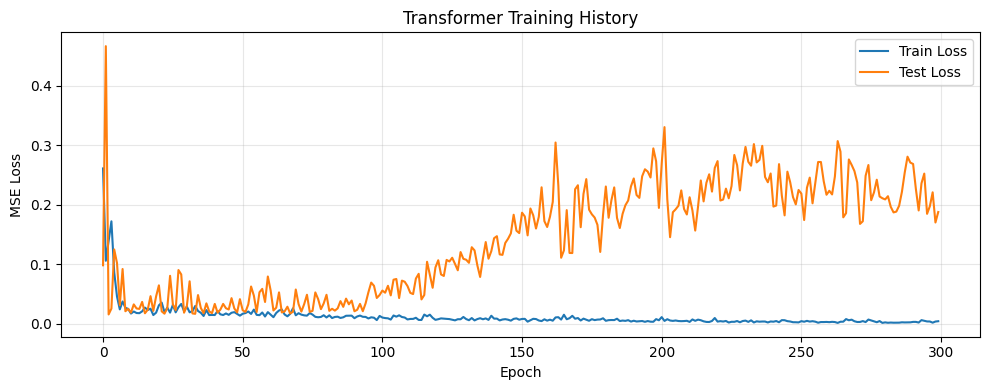

In [30]:
# =========================================================
# 14. Plot loss curves
# =========================================================
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.title("Transformer Training History")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Test RMSE: 9.2650
Test MAE : 8.6769


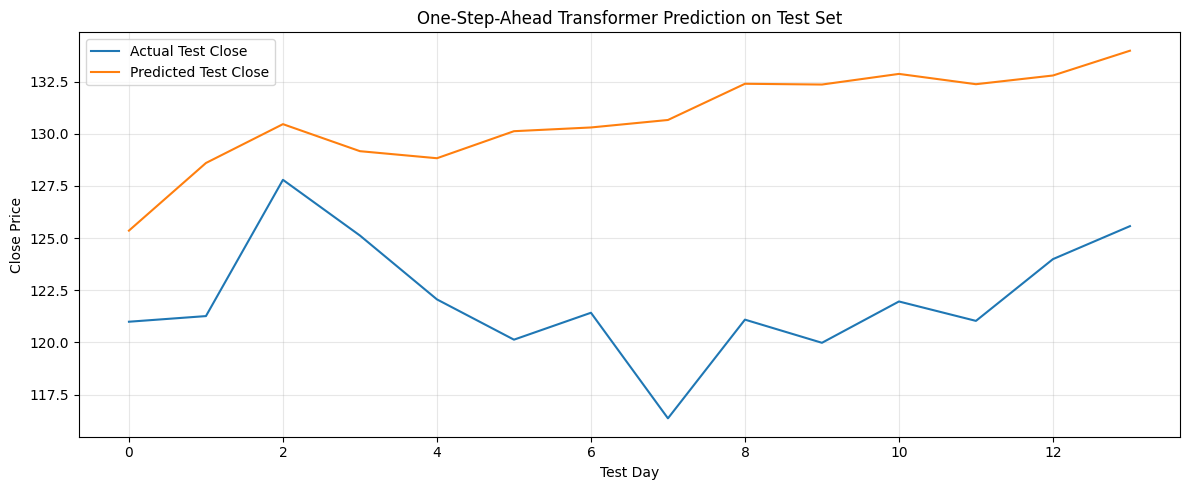

In [31]:
# =========================================================
# 15. One-step prediction on test set
# =========================================================
model.eval()
preds_scaled = []
targets_scaled = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy()

        preds_scaled.append(pred)
        targets_scaled.append(yb.numpy())

preds_scaled = np.concatenate(preds_scaled, axis=0)
targets_scaled = np.concatenate(targets_scaled, axis=0)

preds = scaler.inverse_transform(preds_scaled).flatten()
targets = scaler.inverse_transform(targets_scaled).flatten()

rmse = np.sqrt(mean_squared_error(targets, preds))
mae = mean_absolute_error(targets, preds)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE : {mae:.4f}")

plt.figure(figsize=(12, 5))
plt.plot(targets, label="Actual Test Close")
plt.plot(preds, label="Predicted Test Close")
plt.title("One-Step-Ahead Transformer Prediction on Test Set")
plt.xlabel("Test Day")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
# =========================================================
# 16. Recursive multi-step forecasting
# =========================================================
def recursive_forecast(model, last_window, future_steps, device):
    model.eval()
    window = last_window.copy()
    future_preds_scaled = []

    for _ in range(future_steps):
        x = torch.tensor(window, dtype=torch.float32).reshape(1, len(window), 1).to(device)

        with torch.no_grad():
            next_pred = model(x).item()

        future_preds_scaled.append(next_pred)
        window = np.append(window[1:], next_pred)

    return np.array(future_preds_scaled, dtype=np.float32)

future_steps = 10

full_scaled = scaler.transform(series.reshape(-1, 1)).flatten()
last_window = full_scaled[-LOOKBACK:]

future_scaled = recursive_forecast(
    model=model,
    last_window=last_window,
    future_steps=future_steps,
    device=device
)

future_prices = scaler.inverse_transform(future_scaled.reshape(-1, 1)).flatten()

print("\nRecursive forecast for next", future_steps, "business days:")
for i, price in enumerate(future_prices, start=1):
    print(f"Day +{i}: {price:.2f}")


Recursive forecast for next 10 business days:
Day +1: 135.30
Day +2: 136.08
Day +3: 135.43
Day +4: 129.90
Day +5: 128.53
Day +6: 129.73
Day +7: 131.36
Day +8: 130.83
Day +9: 130.05
Day +10: 128.76


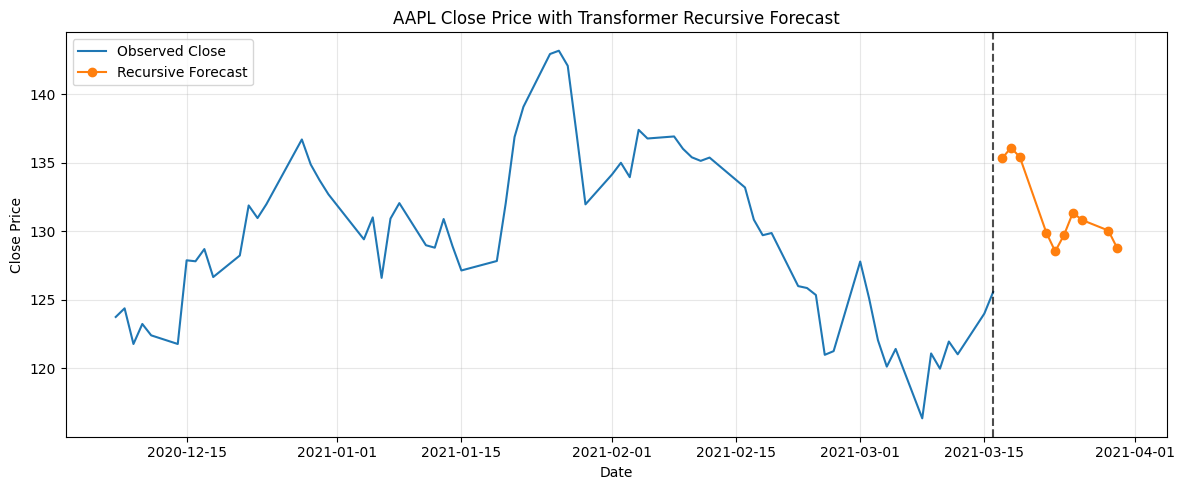

In [33]:
# =========================================================
# 17. Plot observed series + future forecast
# =========================================================
future_dates = pd.date_range(
    start=df["Date"].iloc[-1] + pd.Timedelta(days=1),
    periods=future_steps,
    freq="B"
)

plt.figure(figsize=(12, 5))
plt.plot(df["Date"], series, label="Observed Close")
plt.plot(future_dates, future_prices, marker="o", label="Recursive Forecast")
plt.axvline(df["Date"].iloc[-1], color="black", linestyle="--", alpha=0.7)
plt.title("AAPL Close Price with Transformer Recursive Forecast")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

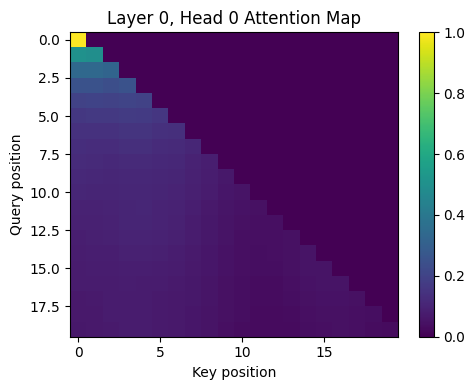

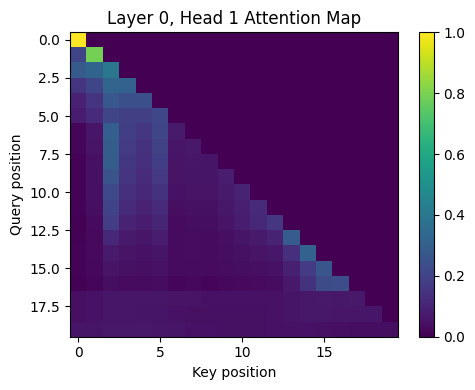

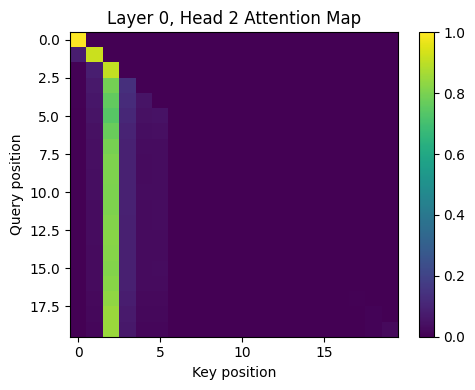

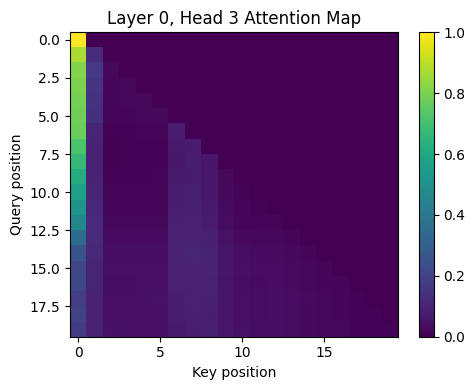

In [34]:
# =========================================================
# 18. Inspect attention weights from the first test sample
# =========================================================
model.eval()
sample_x = X_test[0:1].to(device)

with torch.no_grad():
    sample_pred, all_attention = model(sample_x, return_attention=True)

# all_attention[layer] shape: (batch, heads, seq_len, seq_len)
first_layer_attn = all_attention[0][0].cpu().numpy()  # (heads, seq_len, seq_len)

for h in range(first_layer_attn.shape[0]):
    plt.figure(figsize=(5, 4))
    plt.imshow(first_layer_attn[h], cmap="viridis", aspect="auto")
    plt.colorbar()
    plt.title(f"Layer 0, Head {h} Attention Map")
    plt.xlabel("Key position")
    plt.ylabel("Query position")
    plt.tight_layout()
    plt.show()